# Predictive Maintenance Equipment Dataset For ML

Sensor data from PLC controllers linked to five distinct pieces of equipment, namely, Pump, Extruder, Pressure Cutter, Gauge Machine, and Coil Oven, is utilized to compile the dataset. This dataset encompasses information such as equipment temperature, humidity, age, and the quantity produced during machine failures. Additionally, the Training dataset incorporates the Mean Time to Failures (MTTF) as a maintenance metric.

Additional Information:

Presence of Missing Values:  
No

The dataset comprises 5000 data points organized in rows and features seven attributes arranged in columns. The Unique Identifier (UID) serves as a distinctive marker for each data observation.

Fonte: [Kaggle - Predictive Maintenance Equipment Dataset For ML](https://www.kaggle.com/datasets/stratographics/predictive-maintenance-equipment-dataset-for-ml)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("stratographics/predictive-maintenance-equipment-dataset-for-ml")

print("Path to dataset files:", path)

100%|██████████| 470k/470k [00:00<00:00, 52.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/stratographics/predictive-maintenance-equipment-dataset-for-ml/versions/2


In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split


In [3]:
print(os.listdir(path))

['PM DATA Training.xlsx', 'PM Data Testing.xlsx']


In [4]:
df = pd.read_excel(path + "/" + 'PM DATA Training.xlsx', index_col = "UID")

In [5]:
df.head()

,ProductType,Humidity,Temperature,Age,Quantity,MTTF
UID,,,,,,
1,Extruder,5.88,66.17,13,39764,69
2,Pressure Cutter,42.76,40.29,4,45181,532
3,Extruder,76.62,52.08,4,70397,93
4,Pump,45.91,90.26,14,49470,183
5,Gauge Machine,78.87,58.56,12,45145,447


In [6]:
df.columns = df.columns.str.strip()

In [7]:
df = pd.get_dummies(df, drop_first = True, dtype=int)
df.shape

(5000, 9)

In [8]:
visao_por_ano = df.groupby(by=["Age"]).mean(numeric_only=True).round(2)
visao_por_ano

,Humidity,Temperature,Quantity,MTTF,ProductType_Extruder,ProductType_Gauge Machine,ProductType_Pressure Cutter,ProductType_Pump
Age,,,,,,,,
1,50.05,66.28,50765.88,323.66,0.24,0.24,0.19,0.19
2,52.29,64.09,50012.99,318.60,0.24,0.20,0.16,0.20
3,51.51,64.75,50908.42,310.06,0.21,0.21,0.19,0.24
4,50.93,64.39,52781.31,309.61,0.26,0.20,0.17,0.16
5,54.38,63.59,50820.46,310.61,0.24,0.22,0.21,0.15
6,55.10,63.30,50234.88,328.32,0.24,0.20,0.18,0.17
7,50.09,65.80,50858.58,319.50,0.14,0.16,0.22,0.25
8,51.20,64.29,51171.19,302.40,0.17,0.22,0.21,0.20
9,51.01,65.12,51480.21,317.67,0.22,0.20,0.20,0.20


A partir daqui é possível perceber que estas dados são sintéticos. Conforme estudos de engenharia da manutenção, os equipamentos traçam ao longo dos anos a chamada curva da banheira, onde o MTTF e outros indicadores de manutenção tem valor inicial alto devido a pouca expertise sobre a maquina nova e necessidade de ajustes nos sistemas. Posteriormente, estes índices decaem, dado que a aquisição de conhecimento dos manutentores aumenta e todos os ajustes necessários são realizados. Por fim, o término da vida útil das maquinas provoca alta nas falhas dos equipamentos, e consequentemente, nos resultados dos indicadores.

Ou seja, esperava-se que ao menos nos primeiros anos houvesse um MTTF alto, pois não é sabido se 17 anos de operação representam o fim de vida útil dos equipamentos deste dataset.

Para certificar de que a observação é correta, tentarei estipular um baseline usando uma regressão múltipla.

In [9]:
X = df.drop(columns=["MTTF"])
y = df["MTTF"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=23)

In [11]:
reg = LinearRegression()
baseline = reg.fit(X_train,y_train)

In [12]:
baseline.predict(X_test)

array([319.14325289, 312.54335145, 324.14010148, ..., 327.04647844,
       311.4033251 , 326.49702113])

In [28]:
print(f"O resultado da prediçção no treinamento é: {round(baseline.score(X_test, y_test),3)}")

O resultado da prediçção no treinamento é: -0.001


Como pode ser visto acima, a regressão não conseguiu encontrar nenhuma relação entre os dados.

A seguir, farei uma verificação visual das correlações.

<Axes: >

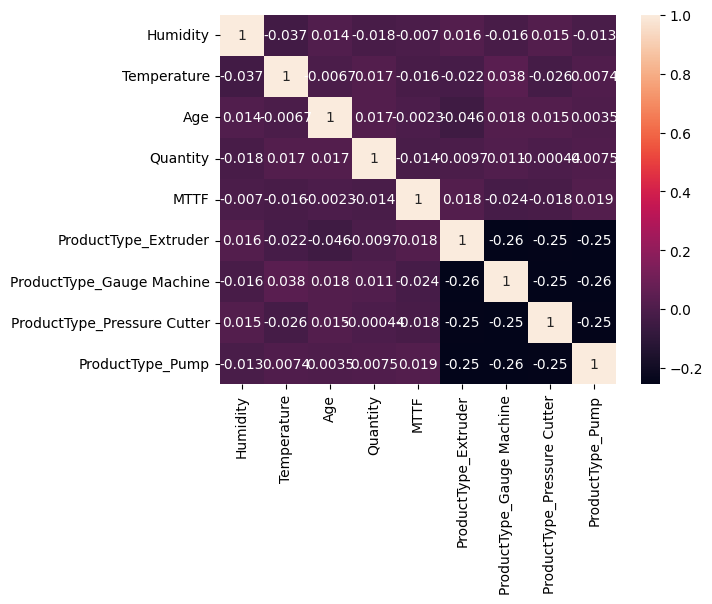

In [14]:
sns.heatmap(df.corr(), annot = True)

Como pode ser visto, nenhuma correlação presente. A seguir, irei capturar os valores mais relevante para análise.

In [15]:
# Verificando as maiores correlações
duplas = df.corr().unstack()
duplas_filtro = duplas[duplas.index.get_level_values(0) != duplas.index.get_level_values(1)]
top5_corr = duplas_filtro.sort_values(ascending=False).drop_duplicates()

print(top5_corr.head())


ProductType_Gauge Machine  Temperature             0.038252
MTTF                       ProductType_Pump        0.018577
ProductType_Gauge Machine  Age                     0.017715
MTTF                       ProductType_Extruder    0.017617
Age                        Quantity                0.017475
dtype: float64


---

Insistindo no tema, vou procurar por correlações complexas.

In [16]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [17]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("Regressor", Ridge())
])

In [18]:
kf = KFold(n_splits=6, random_state=23, shuffle=True)

In [19]:
parametros = [{"Regressor": [Ridge()],
               "Regressor__alpha": [0.1,1.0,10.0]
               },
              {"Regressor": [KNeighborsRegressor()],
               "Regressor__n_neighbors":[3,5,7]
               },
              {
                "Regressor":[DecisionTreeRegressor(random_state=23)],
                "Regressor__max_depth":[None,5,10]
              },
              {
                "Regressor":[RandomForestRegressor()],
                "Regressor__n_estimators":[50,100],
                "Regressor__max_depth":[None,5,10]

              },
              {
                "Regressor":[GradientBoostingRegressor(random_state=23)],
                "Regressor__n_estimators":[50,100],
                "Regressor__learning_rate":[0.05,0.1]
              }

]


In [20]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=parametros,
    cv=kf,
    scoring="r2",
    n_jobs=-1
)

In [23]:
grid_search.fit(X_train, y_train)


O melhor modelo e sua configuração ótima é:{'Regressor': Ridge(), 'Regressor__alpha': 10.0}
Resultado:(0, 2)


In [25]:
print(f"O melhor modelo e sua configuração ótima é:{grid_search.best_params_}")
print(f"Resultado:{round(grid_search.best_score_,3)}")

O melhor modelo e sua configuração ótima é:{'Regressor': Ridge(), 'Regressor__alpha': 10.0}
Resultado:-0.004


## Conclusão:
De diversas formas foi possível identificar a falta de padrões nos dados impossibilitando analises complexas.  

Embora os dados não sejam os ideais, pude demonstrar uma primeira abordagem das informações, demonstrando o raciocínio da exploração de dados de manutenção  captando informações intrínsecas baseado no meu conhecimento de manutenção industrial.